In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib

In [2]:
# load the dataset
titanic_data=pd.read_csv('Titanic-Dataset.csv')

In [5]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
titanic_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [99]:
# create pivot table between survived and sex
survived_and_sex=pd.pivot_table(titanic_data,values='Survived',index='Sex',aggfunc='mean')

# create pivot table between survived and age
age_bins = pd.cut(titanic_data['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 80])
survived_and_age = pd.pivot_table(titanic_data, values='Survived', index=age_bins, aggfunc='mean',observed=False)

# create pivot table between survived and Pclass
survived_and_pclass=pd.pivot_table(titanic_data,values='Survived',index='Pclass',aggfunc='mean')

# create pivot table between survived and siblings_and_spouse
survived_and_sibling_and_spouse=pd.pivot_table(titanic_data,values='Survived',index='SibSp',aggfunc='mean')

# create pivot table between survived and parents_and_children
survived_and_parent_and_children=pd.pivot_table(titanic_data,values='Survived',index='Parch',aggfunc='mean')

# create pivot table between survived and fare (ticket price)
survived_and_pclass_and_fare=pd.pivot_table(titanic_data,values='Fare',index=['Survived','Pclass'],aggfunc='mean')

# create pivot table between survived and embarked
survived_and_embarked=pd.pivot_table(titanic_data,values='Survived',index='Embarked',aggfunc='mean')

# create pivot table between survived and cabin
survived_and_cabin=pd.pivot_table(titanic_data,values='Survived',index='Cabin',aggfunc='mean')

# create pivot table between survived and family
survived_and_family=pd.pivot_table(titanic_data,values='Survived',index=['Parch','SibSp'],aggfunc='mean')

# create pivot table between survived and age_and_sex
survived_and_age_and_sex=pd.pivot_table(titanic_data,values='Survived',index=['Age','Sex'],aggfunc='mean')


In [19]:
def create_barplot(data, start, end, xlabel='None', ylabel='None', title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a bar plot for the specified subset of the data, with color gradient based on the values.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the bars. Default is 'red'.

    Returns:
        None: Displays the bar plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset.columns[0]
    
    norm = mcolors.Normalize(vmin=subset[values].min(), vmax=subset[values].max())
    cmap = matplotlib.colormaps[colormap]  
    color = [cmap(norm(value)) for value in subset[values]]
    
    sns.barplot(data=subset, x=subset.index, y=subset[values], palette=color,width=0.5, hue=subset.index)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

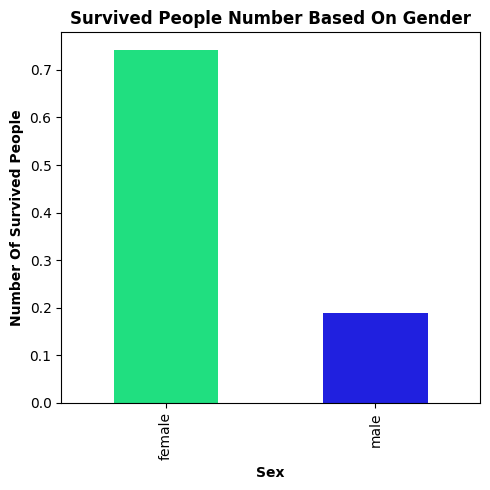

In [20]:
create_barplot(survived_and_sex,0,2,'Sex','Number Of Survived People','Survived People Number Based On Gender',5,5,'winter')

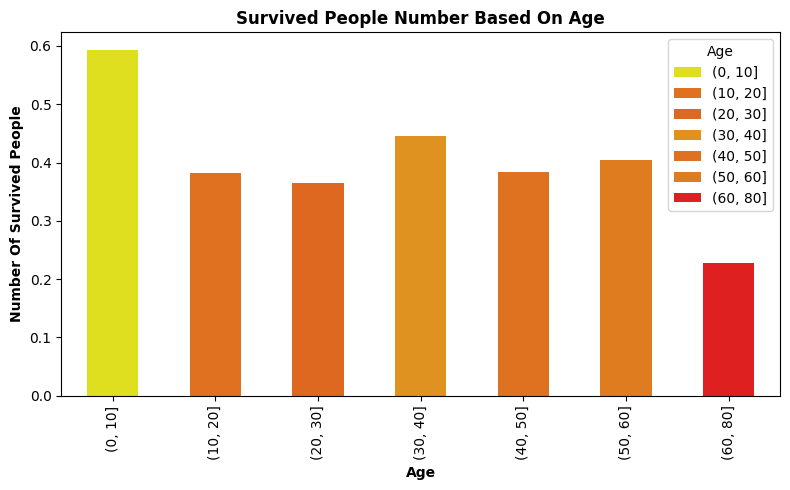

In [21]:
create_barplot(survived_and_age,0,7,'Age','Number Of Survived People','Survived People Number Based On Age',8,5,'autumn')

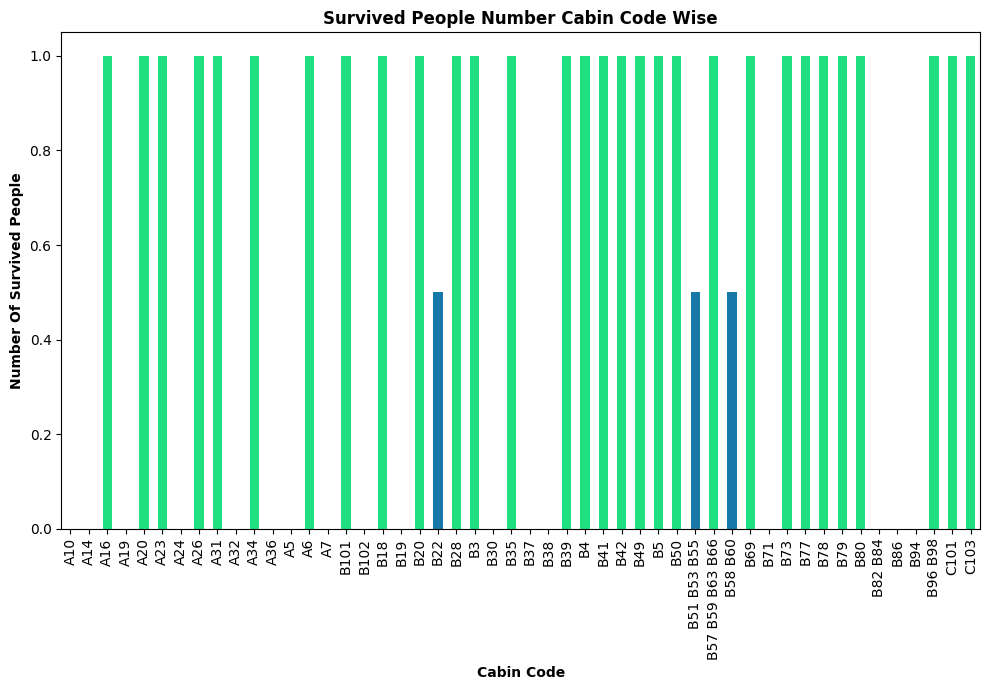

In [44]:
create_barplot(survived_and_cabin,0,50,'Cabin Code','Number Of Survived People','Survived People Number Cabin Code Wise',10,7,'winter')

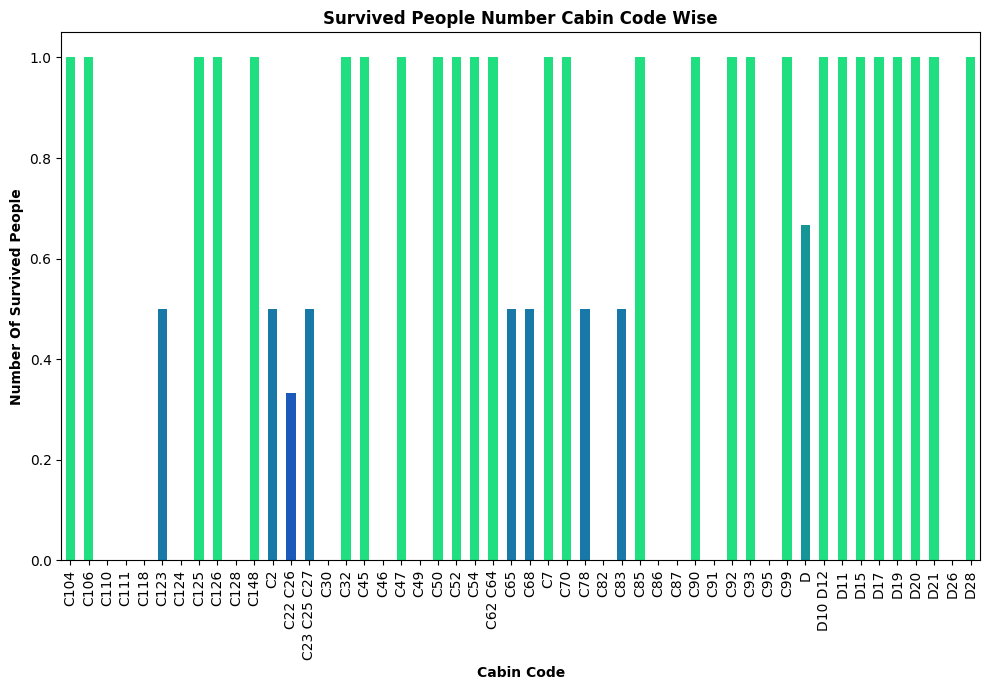

In [50]:
create_barplot(survived_and_cabin,50,100,'Cabin Code','Number Of Survived People','Survived People Number Cabin Code Wise',10,7,'winter')

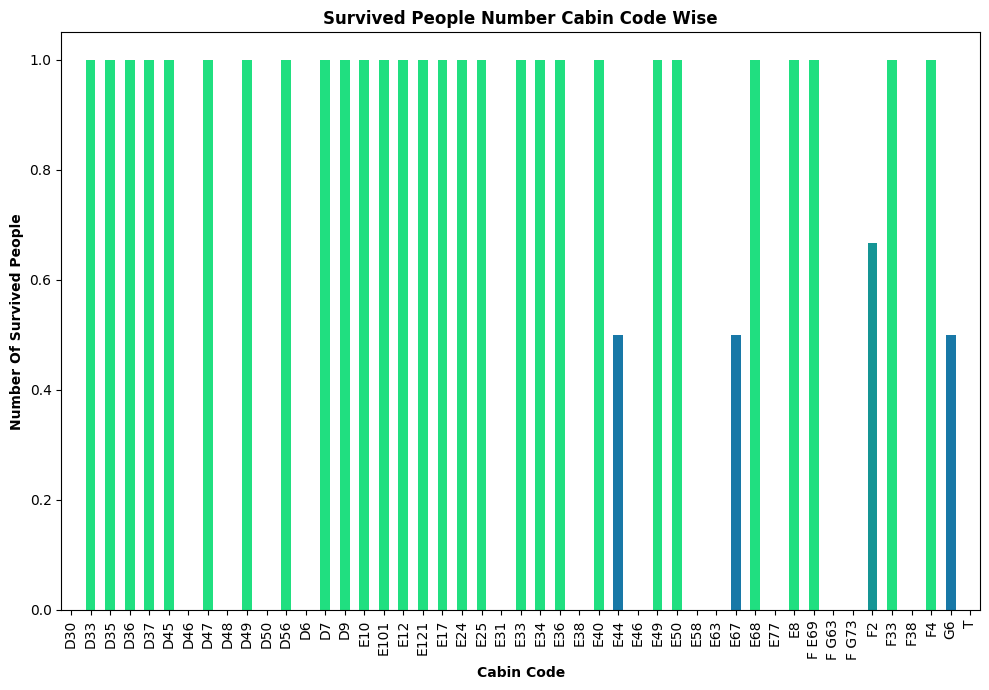

In [61]:
create_barplot(survived_and_cabin,100,150,'Cabin Code','Number Of Survived People','Survived People Number Cabin Code Wise',10,7,'winter')

In [66]:
def create_pieplot(data,start,end,title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a pie plot for a specified subset of data, with the colors of the slices 
    mapped based on the values of the data.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        title (str, optional): The title of the plot. Default is 'Data'.
        fig_width (int, optional): The width of the figure. Default is 20.
        fig_height (int, optional): The height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the pie slices. Default is 'Reds'.

    Returns:
        None: Displays the pie plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset[subset.columns[0]]
    
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    cmap = matplotlib.cm.get_cmap(colormap)  
    color = [cmap(norm(value)) for value in values]
    
    plt.pie(values, labels=subset.index, autopct='%1.1f%%', colors=color, startangle=0,
            pctdistance=0.75, labeldistance=1.1)
    plt.title(title, fontweight='bold')
    plt.axis('equal')
    plt.show()

C:\Users\sarju\AppData\Local\Temp\ipykernel_19824\3453224930.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap(colormap)


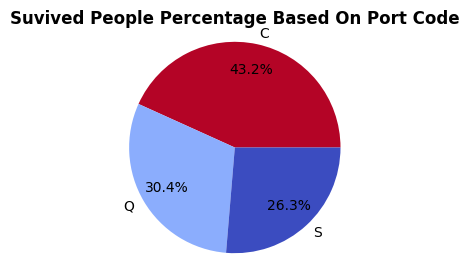

In [86]:
create_pieplot(survived_and_embarked,0,3,'Suvived People Percentage Based On Port Code',3,3,'coolwarm')

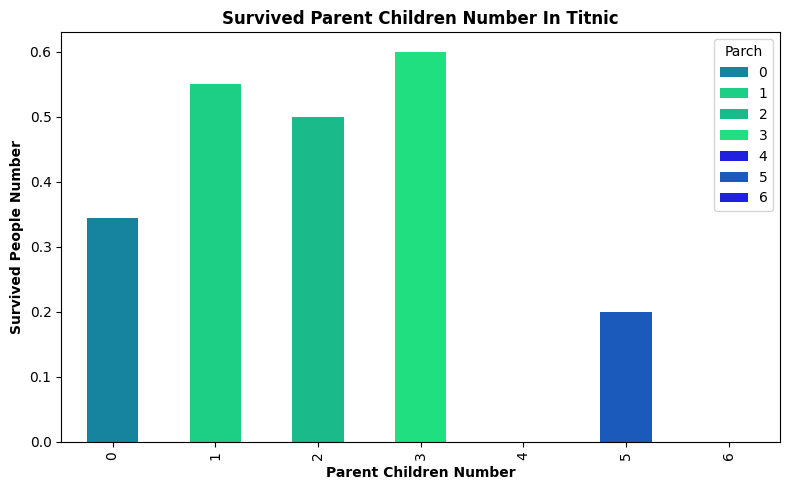

In [116]:
create_barplot(survived_and_parent_and_children,0,7,'Parent Children Number','Survived People Number','Survived Parent Children Number In Titnic',8,5,'winter')

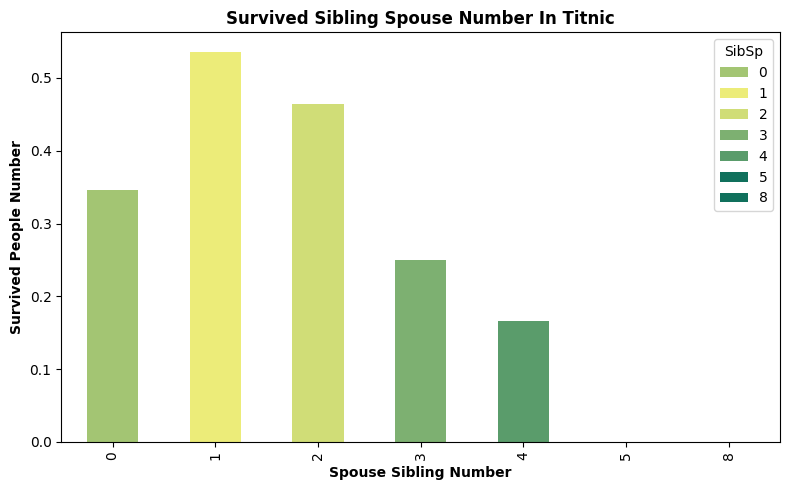

In [119]:
create_barplot(survived_and_sibling_and_spouse,0,7,'Spouse Sibling Number','Survived People Number','Survived Sibling Spouse Number In Titnic',8,5,'summer')

C:\Users\sarju\AppData\Local\Temp\ipykernel_19824\3453224930.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap(colormap)


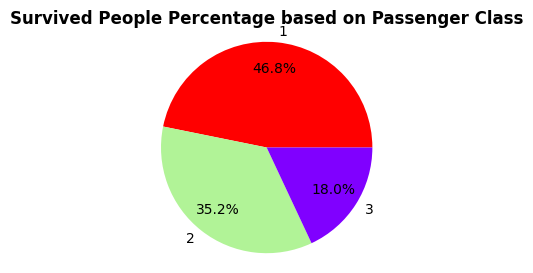

In [126]:
create_pieplot(survived_and_pclass,0,3,'Survived People Percentage based on Passenger Class',3,3,'rainbow')